# Testing the visualizations

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [7]:

ds = xr.open_dataset("unified_annual_carbon_dataset_2015_2024.nc")
out_root = Path("csv_by_variable_and_time")
out_root.mkdir(parents=True, exist_ok=True)

def detect_spatial_dims(da):
    if "lat" in da.dims and "lon" in da.dims:
        return "lat", "lon"
    if "latitude" in da.dims and "longitude" in da.dims:
        return "latitude", "longitude"
    raise ValueError(f"Unsupported spatial dims for {da.name}: {da.dims}")

def time_to_label(t):
    t_arr = np.array(t)
    if np.issubdtype(t_arr.dtype, np.integer):
        return str(int(t))
    try:
        return np.datetime_as_string(np.datetime64(t), unit="D")
    except Exception:
        return str(t)

for var_name, da in ds.data_vars.items():
    if "time" not in da.dims:
        continue

    lat_dim, lon_dim = detect_spatial_dims(da)
    var_out = out_root / var_name
    var_out.mkdir(parents=True, exist_ok=True)

    for t in ds["time"].values:
        da_t = da.sel(time=t)

        lat_vals = da_t[lat_dim].values
        lon_vals = da_t[lon_dim].values
        vals = da_t.values  # 2D array: [lat, lon] or [latitude, longitude]

        # Build flat table directly from array + meshgrid
        lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
    
        vals = np.nan_to_num(da_t.values, nan=0.0, posinf=0.0, neginf=0.0)

        df = pd.DataFrame({
            "lat": lat_grid.ravel(),
            "lon": lon_grid.ravel(),
            var_name: vals.reshape(-1),
        })
        df[var_name] = df[var_name].fillna(0.0)

        out_file = var_out / f"{var_name}_time={time_to_label(t)}.csv"
        df.to_csv(out_file, index=False)#, compression="snappy")

        # Optional sanity check
        non_null = df[var_name].notna().sum()
        if non_null == 0:
            print(f"Warning: {var_name} at time={t} is all NaN in source data")

    print(f"Wrote {var_name}")

Wrote growth_rate
Wrote emission
Wrote gosif
Wrote delta_emission
Wrote delta_gosif
Wrote cams_xco2
Wrote growth_err
Wrote mean_co2


In [31]:
check = pd.read_csv("csv_by_variable_and_time\\emission\\emission_time=2015.csv")
print(check.head())
print(check["emission"].isna().mean(), "fraction NaN")
print(check["emission"].describe())

    lat    lon  emission
0 -89.5 -179.5       0.0
1 -89.5 -178.5       0.0
2 -89.5 -177.5       0.0
3 -89.5 -176.5       0.0
4 -89.5 -175.5       0.0
0.0 fraction NaN
count    6.480000e+04
mean     5.650678e+03
std      4.572364e+04
min      0.000000e+00
25%      1.124687e+00
50%      3.841523e+01
75%      2.440732e+02
max      3.544554e+06
Name: emission, dtype: float64


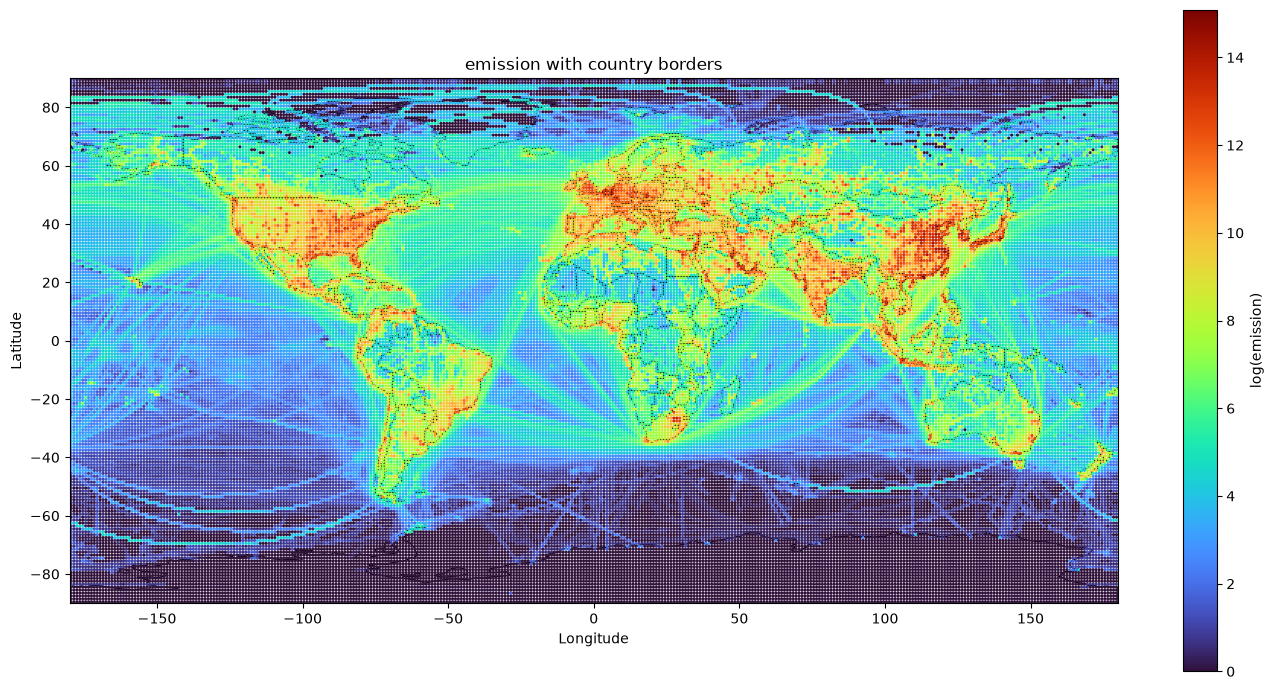

In [32]:
import geopandas as gpd
from pathlib import Path

# Cache borders locally after first download
borders_path = Path("ne_110m_admin_0_countries.gpkg")
if not borders_path.exists():
    world = gpd.read_file(
        "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    )
    world.to_file(borders_path, driver="GPKG")
else:
    world = gpd.read_file(borders_path)

value_cols = [c for c in check.columns if c not in ["lat", "lon"]]
value_col = value_cols[0]

# Keep only positive values for log scale
plot_df = check[check[value_col] >= 0].dropna(subset=["lat", "lon", value_col]).copy()

fig, ax = plt.subplots(figsize=(14, 7))

# 1) Draw country borders first (background layer)
world.plot(
    ax=ax,
    facecolor="none",       # transparent fill
    edgecolor="black",
    linewidth=1,
    alpha=1
)

# 2) Scatter the data on top
sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=np.log1p(plot_df[value_col]),   # log1p safe for 0s
    s=5,
    cmap="turbo",
    linewidths=0,
    alpha=1,
    zorder=2                # ensure data sits above borders
)

plt.colorbar(sc, ax=ax, label=f"log({value_col})")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"{value_col} with country borders")
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd

from bokeh.io import output_notebook, show
from bokeh.models import (
    ColumnDataSource, LogColorMapper, ColorBar, BasicTicker, LogTicker,
    NumeralTickFormatter, HoverTool
)
from bokeh.plotting import figure
from bokeh.palettes import Turbo256

output_notebook()

# 1) Detect the value column (everything except lat/lon)
value_cols = [c for c in check.columns if c not in ["lat", "lon"]]
if not value_cols:
    raise ValueError("No data variable column found in check.")
value_col = value_cols[0]

# 2) Keep only finite rows and positive values (required for log scale)
plot_df = check[["lat", "lon", value_col]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["lat", "lon", value_col])
plot_df = plot_df[plot_df[value_col] > 0].copy()

if plot_df.empty:
    raise ValueError("No positive non-NaN values available for log-scale plotting.")

# 3) Optional: quantile clipping for better color contrast
#    This prevents a few extreme values from washing out the map.
low_q, high_q = plot_df[value_col].quantile([0.01, 0.99])
plot_df["val_clipped"] = plot_df[value_col].clip(lower=low_q, upper=high_q)

# 4) Build color mapper on clipped values
vmin = float(plot_df["val_clipped"].min())
vmax = float(plot_df["val_clipped"].max())
if vmin <= 0:
    vmin = float(plot_df.loc[plot_df["val_clipped"] > 0, "val_clipped"].min())

mapper = LogColorMapper(palette=Turbo256, low=vmin, high=vmax)

source = ColumnDataSource(plot_df)

# 5) High-resolution interactive figure
p = figure(
    title=f"{value_col} map (log color, non-NaN positive values)",
    width=700,     # increase resolution
    height=325,     # increase resolution
    x_axis_label="Longitude",
    y_axis_label="Latitude",
    tools="pan,wheel_zoom,box_zoom,lasso_select,reset,save",
    active_scroll="wheel_zoom",
    match_aspect=True
)

# Small markers for dense grid; higher alpha improves visual blending
r = p.circle(
    x="lon",
    y="lat",
    source=source,
    size=3,
    alpha=0.85,
    line_alpha=0,
    fill_color={"field": "val_clipped", "transform": mapper}
)

hover = HoverTool(
    renderers=[r],
    tooltips=[
        ("lon", "@lon{0.00}"),
        ("lat", "@lat{0.00}"),
        (value_col, f"@{value_col}{{0.000}}"),
        ("clipped", "@val_clipped{0.000}")
    ]
)
p.add_tools(hover)

color_bar = ColorBar(
    color_mapper=mapper,
    ticker=LogTicker(),
    formatter=NumeralTickFormatter(format="0.00a"),
    label_standoff=8,
    location=(0, 0),
    title=f"{value_col} (log scale)"
)
p.add_layout(color_bar, "right")

p.grid.visible = True
p.grid.grid_line_alpha = 0.2

show(p)

Loading BokehJS ...

In [10]:
import geopandas as gpd
import pandas as pd
import plotly.express as px

# 1. Create sample dataset
data = {
    "latitude": check["lat"].tolist(),
    "longitude": check["lon"].tolist(),
    "emissions": check["emission"].tolist(),
}
df = pd.DataFrame(data)

# 2. Convert to GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326"
)

# 3. Load political borders via URL 
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

# 4. Spatial Join
enriched_gdf = gpd.sjoin(gdf_points, world, how="left", predicate="within")

# FIXED: Changed 'name' to 'NAME' to match the new dataset columns
print(enriched_gdf[["latitude", "longitude", "emissions", "NAME"]])

# 5. Plot Interactive Map
fig = px.scatter_mapbox(
    enriched_gdf,
    lat="latitude",
    lon="longitude",
    color="emissions",
    size="emissions",
    hover_name="NAME",  # FIXED HERE TOO
    hover_data=["emissions"],
    zoom=1,
    mapbox_style="carto-positron",
)

fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()

       latitude  longitude  emissions        NAME
0         -89.5     -179.5   0.000000  Antarctica
1         -89.5     -178.5   0.000000  Antarctica
2         -89.5     -177.5   0.000000  Antarctica
3         -89.5     -176.5   0.000000  Antarctica
4         -89.5     -175.5   0.000000  Antarctica
...         ...        ...        ...         ...
64795      89.5      175.5   0.000000         NaN
64796      89.5      176.5   0.000000         NaN
64797      89.5      177.5   0.000000         NaN
64798      89.5      178.5   1.197402         NaN
64799      89.5      179.5   1.197402         NaN

[64800 rows x 4 columns]


C:\Users\darja\AppData\Local\Temp\ipykernel_19624\1457968597.py:29: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [12]:
output_filename = "emissions_interactive_map.html"
fig.write_html(output_filename, config={"scrollZoom": True}, auto_open=True)